## Curso 4, Parte A: Laboratorio de Agrupamiento de K-Medias

__Propósito:__
El propósito de este ejercicio de laboratorio es aprender a usar un algoritmo de aprendizaje no supervisado, **K-means**, con sklearn.

__Al finalizar este laboratorio, podrá:__
> 1. Ejecutar un algoritmo K-means.
> 2. Comprender qué parámetros se pueden personalizar para el algoritmo.
> 3. Saber usar la curva de inercia para determinar el número óptimo de clústeres.

Ejemplo de aplicación de clústeres:
- Clasificación.
- Detección de anomalías.
- Segmentación de clientes: Agrupaciones que ayudan a determinar cuantos tipos de cliente tiene la empresa en función de la frecuencia
- Mejorar los modelos de aprendizaje supervisado: Puedes comprobar un buen modelo de regresión logística y comparar su rendimiento en comparación con los modelos entrenados para subsegmentos de tus datos que encontraste mediante la agrupación en clústeres.

#  K-Medias

**K-Medias** es uno de los algoritmos de agrupamiento más básicos. Se basa en encontrar los centros de los conglomerados para agrupar los puntos de datos, minimizando la suma de los errores cuadrados entre cada punto de datos y su centro.

**Pasos del algoritmo k-means:**
1. Elegir aleatoriamente $k$ centroides de los ejemplos como centros de clústeres iniciales.
2. Asignar cada ejemplo al centroide más cercano, $\mu ^{(j)}$, $j \in \{ 1, \ldots, k \}$
3. Mover los centroides al centro de los ejemplos que le fueron asignados.
4. Repetir los pasos $2$ y $3$ hasta que las asignaciones de los clústeres no cambien o se alcance una tolerancia definida por el usuario o se llegue a un número máximo de iteraciones.


Otra forma de mejorar la optimización del algoritmo **k-means** es realizar una inicialización más inteligente de los centroides. En muchos casos, las soluciones subóptimas o mínimos locales aparecen cuando dos centroides se inicializan demasiado cerca entre sí. Para evitar este problema, es recomendable comenzar con centroides que estén suficientemente alejados unos de otros, lo que favorece una mejor convergencia del algoritmo.
- Situar los centroides iniciales lejos unos de otros mediante el algoritmo **k-medias++**, que conduce a resultados mejores y más consistentes que el clásico **k-means**.


## K-Medias++

**Pasos del algoritmo k-means++:**
1. Inicializar un conjunto vacío, **M**, para almacenar los $k$ centroides que se van a seleccionar.
2. Elegir al azar el primer centroide, $\mu ^{j}$, de los ejemplos de entrada y asignarlo a **M**.
3. Para cada ejemplo, $x^{(i)}$, que no está en **M**, encontrar la distancia mínima al cuadrado, $d(x^{(i)}, M)^2$, a cualquiera de los centroides en **M**.
4. Para poder seleccionar aleatoriamente el siguiente centroide, $\mu ^{(p)}$, se utiliza una distribución de probabilidad ponderada igual a $\frac{d(\mu ^{(p)}, M)^2} {\sum _i d(x^{(i)}, M)^2 }$. Por ejemplo, recogemos todos los puntos de un array y elegimos un muestreo aleatorio ponderado, de forma que cuanto mayor sea la distancia al cuadrado, más probable será que un punto sea elegido como centroide.
5. Repetir los pasos $3$ y $4$ hasta que se elijan $k$ centroides.
6. Proceder con el algoritmo clásico de **k-means**.

## Inercia y distorsión

Uno de los principales retos del **aprendizaje no supervisado** es que no contamos con una respuesta definitiva o etiquetas reales. Por ello, para evaluar la calidad de un *clustering*, es necesario utilizar **métricas intrínsecas**, como el **SSE (Sum of Squared Errors o distorsión)**, que permiten comparar el rendimiento de distintos modelos de agrupación basados en *k-means*.

La **inercia** es una métrica popular para este propósito, ya que mide la compacidad de los clústeres al cuantificar la suma de las distancias cuadradas entre los puntos y su centroide correspondiente. De esta forma, nos ayuda a comprender cómo se distribuyen los datos y el grado de cohesión interna de los distintos clústeres.

$$\sum \limits _{i=1}^{n} (x_i-C_k)^2 $$

La métrica solo nos dará la suma total de la distancia cuadrada de cada punto a su centroide conglomerado.
- Penalizaremos los clústeres dispersos y recompensaremos los clústeres más estrechos con esos centroides.

**Desventaja de la inercia**
- Este valor dependerá del número de puntos de los clústeres

La **distorción** toma el promedio de las distancias cuadradas desde cada punto hasta el ccentroide del conglomerado.

$$\frac{1}{n} \sum \limits _{i=1}^{n} (x_i-C_k)^2 $$

- Los valores más peequeños corresponderán a conglomerados más estrechos (añadir más puntos no necesariamente aumentará la distorsión)

conclusión: 
- La inercia siempre aumentará a medida que se agreguen más miembros a cada grupo, pero este no será el caso para distorsión, ya que funciona tomando el promedio.
- Cuando la similitud de los puntos del conglomerados es más importante, se debe utilizar la distorsión
- Si importa más que los conglomerados tengan un número similar de puntos, entonces se debe de usar la inercia.

**Inercia vs. Distorsión en *k-means***

En el algoritmo **k-means**, la **inercia** y la **distorsión** son métricas relacionadas, pero evalúan aspectos distintos de la calidad del *clustering*.

**Inercia**

La **inercia** se define como la **suma total de las distancias cuadradas** entre cada punto y el centroide de su clúster.

- A medida que se agregan más puntos a un clúster, la inercia **aumenta**, incluso si los puntos están bien agrupados.
- Está fuertemente influenciada por el **tamaño de los clústeres**.
- Penaliza clústeres grandes, ya que más puntos implican una mayor suma de distancias.

**Se recomienda usar inercia cuando:**
- Es importante que los clústeres tengan un **número similar de observaciones**.
- Se desea evitar conglomerados excesivamente grandes.


**Distorsión**

La **distorsión** suele calcularse como el **promedio de las distancias cuadradas** entre los puntos y su centroide.

- Al ser un promedio, el impacto del número de puntos queda **normalizado**.
- Un clúster puede ser grande y aun así presentar **baja distorsión** si sus puntos son similares.
- Mide principalmente la **cohesión interna** de los clústeres.

**Se recomienda usar distorsión cuando:**
- La **similitud entre los puntos** dentro de cada clúster es lo más importante.
- El tamaño del clúster no debe influir de manera dominante en la evaluación.


Resumen

- **Similitud interna de los clústeres** → usar **distorsión**  
- **Equilibrio en el tamaño de los clústeres** → usar **inercia**

## Método del codo

Desde un punto de vista técnico, tanto la **inercia** como la **distorsión** tienden a **disminuir** a medida que aumenta el número de clústeres ($K$).

- En el caso extremo, si asignáramos **un clúster a cada punto de datos**, la distancia de cada observación a su centroide sería cero, lo que daría como resultado una **inercia y distorsión iguales a cero**.


El **método del codo** se basa en analizar cómo cambia la inercia o la distorsión al incrementar el número de clústeres.

- En el **punto de inflexión**, estas métricas **disminuyen de forma pronunciada**.
- A partir de ese punto, la **tasa de disminución se reduce drásticamente**, lo que indica que agregar más clústeres ya no aporta una mejora significativa.

Este comportamiento sugiere la existencia de un **número natural de agrupaciones** en el conjunto de datos, que suele ser una elección razonable para el valor de $K$.


**Interpretación del punto de inflexión**

En el punto de inflexión:

- La **inercia** penaliza de forma distinta a los clústeres con mayor número de puntos, lo que favorece un **mejor equilibrio en el tamaño de los clústeres**.
- La **distorsión**, al basarse en promedios, tiende a generar **agrupaciones con mayor similitud interna** entre sus puntos.


## Código

In [1]:
def warn(*args, **kwargs): pass              # Función vacía para ignorar warnings
import warnings                              # Módulo para manejo de advertencias
warnings.warn = warn                        # Sobrescribe warnings.warn
warnings.filterwarnings('ignore')           # Ignora todos los warnings


import numpy as np                           # Operaciones numéricas y arreglos
import pandas as pd                          # Manipulación de datos (DataFrames)
import seaborn as sns                        # Visualización estadística
import matplotlib.pyplot as plt              # Gráficos
from sklearn.preprocessing import scale     # Escalado de datos
from sklearn.cluster import KMeans           # Algoritmo K-Means
from sklearn.datasets import make_blobs      # Generación de datos sintéticos
from sklearn.utils import shuffle            # Mezclar datos aleatoriamente


%config InlineBackend.figure_formats = ['retina']  # Gráficos en alta resolución


In [3]:
plt.rcParams['figure.figsize'] = [6, 6]   # Tamaño de la figura (ancho, alto)
sns.set_style("whitegrid")                # Estilo de fondo con cuadrícula blanca
sns.set_context("talk")                   # Tamaño de textos optimizado para presentaciones

La agrupación en clústeres mediante K-medias es uno de los algoritmos más sencillos. Una de sus limitaciones es que depende del punto de partida de los clústeres, y el número de clústeres debe definirse de antemano.

### Puntos de partida del clúster
Comencemos creando un conjunto de datos simple.


In [5]:
# Función auxiliar para mostrar datos en 2D y resaltar clusters
def display_cluster(X, km=[], num_clusters=0):
    color = 'brgcmyk'                          # Colores disponibles para los clusters
    alpha = 0.5                               # Transparencia de los puntos
    s = 20                                    # Tamaño de los puntos

    if num_clusters == 0:                     # Si no hay clusters definidos
        plt.scatter(X[:,0], X[:,1],           # Dibuja todos los puntos
                    c=color[0], alpha=alpha, s=s)
    else:
        for i in range(num_clusters):         # Itera sobre cada cluster
            plt.scatter(X[km.labels_==i,0],   # Puntos pertenecientes al cluster i
                        X[km.labels_==i,1],
                        c=color[i], alpha=alpha, s=s)
            plt.scatter(km.cluster_centers_[i][0],  # Centroide en eje X
                        km.cluster_centers_[i][1],  # Centroide en eje Y
                        c=color[i], marker='x', s=100)  # Marca del centroide


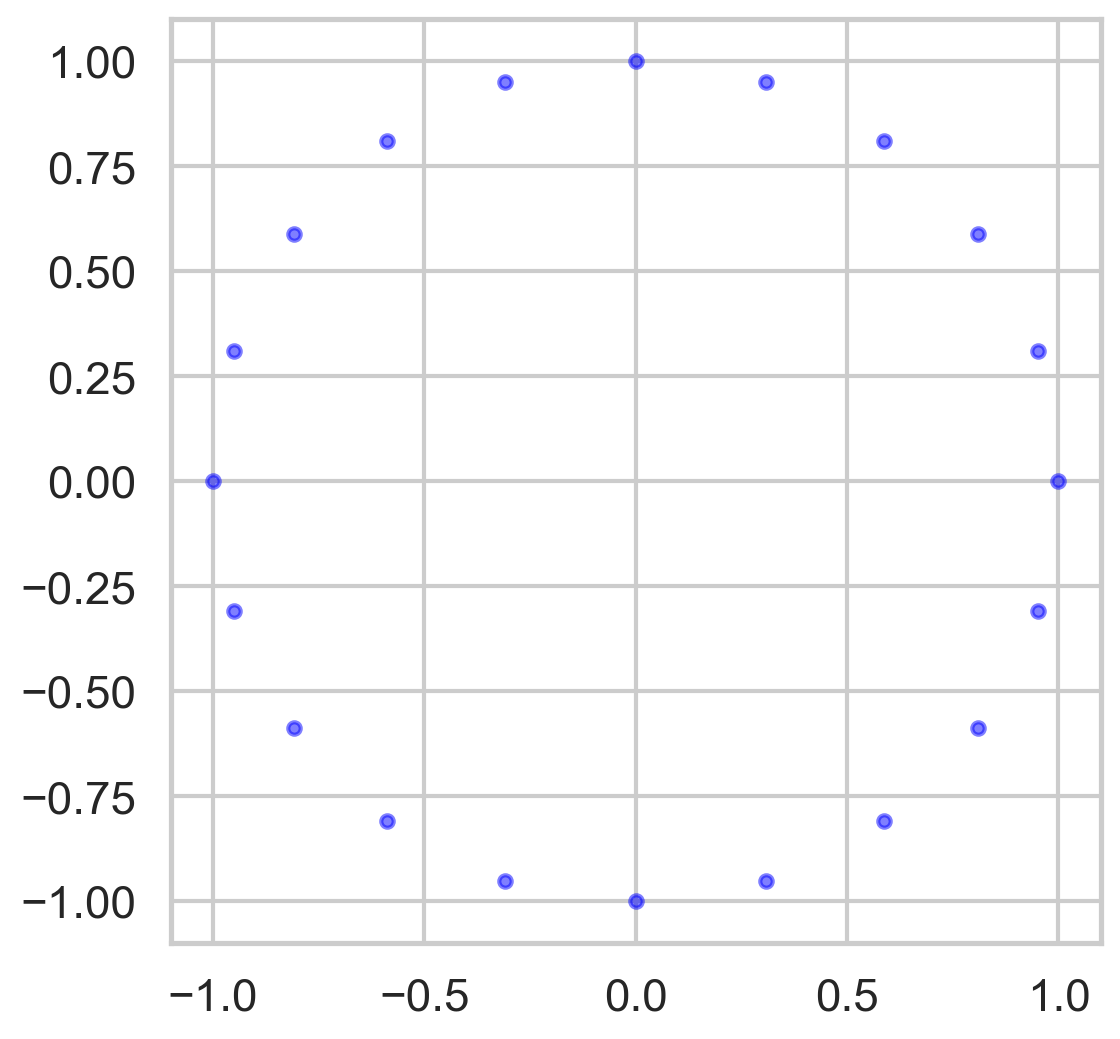

In [7]:
angle = np.linspace(0, 2*np.pi, 20, endpoint=False)   # Genera 20 ángulos entre 0 y 2π
X = np.append([np.cos(angle)],                       # Coordenadas X (coseno)
              [np.sin(angle)],                       # Coordenadas Y (seno)
              0).transpose()                         # Une y transpone para formar la matriz
display_cluster(X)                                   # Muestra los puntos en 2D sin clusters


Agrupemos ahora estos datos en dos clústeres. Usaremos dos estados aleatorios diferentes para inicializar el algoritmo. Establecer la variable __[estado aleatorio](https://numpy.org/doc/stable/reference/random/legacy.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01#numpy.random.RandomState)__ es útil para realizar pruebas y nos permite inicializar la aleatoriedad (para obtener los mismos resultados en cada ocasión).


Agrupamiento con un estado aleatorio de 10:

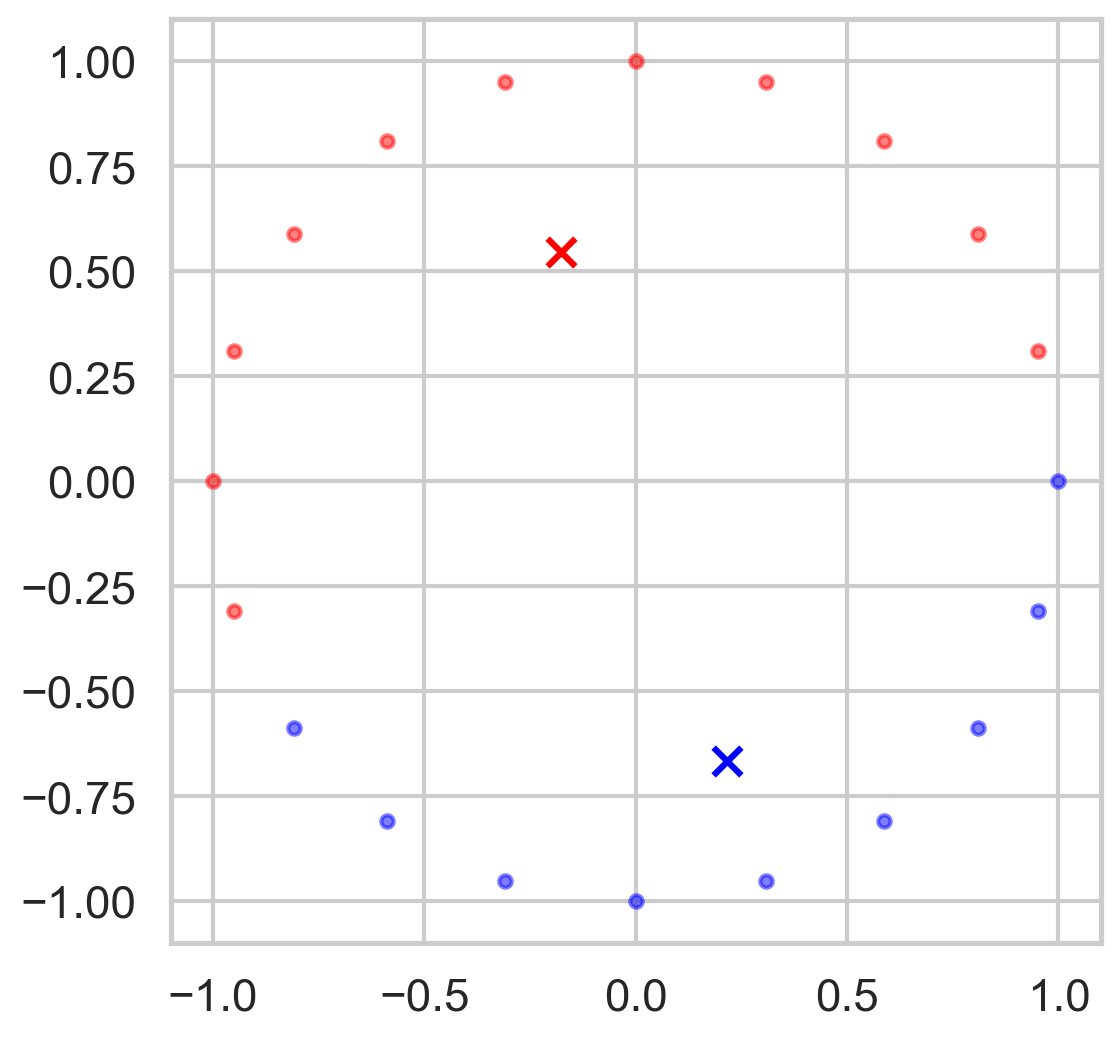

In [9]:
num_clusters = 2                                              # Número de clusters a crear
km = KMeans(n_clusters=num_clusters,                          # Inicializa K-Means
            random_state=10,                                   # Semilla para reproducibilidad
            n_init=1)                                          # Número de ejecuciones del algoritmo
km.fit(X)                                                      # Ajusta el modelo a los datos
display_cluster(X, km, num_clusters)                           # Muestra los clusters y centroides


Localización del centroide

In [11]:
km.cluster_centers_ 

array([[ 0.21678406, -0.66719272],
       [-0.17736877,  0.54588496]])

In [13]:
km.labels_

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [15]:
X

array([[ 1.00000000e+00,  0.00000000e+00],
       [ 9.51056516e-01,  3.09016994e-01],
       [ 8.09016994e-01,  5.87785252e-01],
       [ 5.87785252e-01,  8.09016994e-01],
       [ 3.09016994e-01,  9.51056516e-01],
       [ 6.12323400e-17,  1.00000000e+00],
       [-3.09016994e-01,  9.51056516e-01],
       [-5.87785252e-01,  8.09016994e-01],
       [-8.09016994e-01,  5.87785252e-01],
       [-9.51056516e-01,  3.09016994e-01],
       [-1.00000000e+00,  1.22464680e-16],
       [-9.51056516e-01, -3.09016994e-01],
       [-8.09016994e-01, -5.87785252e-01],
       [-5.87785252e-01, -8.09016994e-01],
       [-3.09016994e-01, -9.51056516e-01],
       [-1.83697020e-16, -1.00000000e+00],
       [ 3.09016994e-01, -9.51056516e-01],
       [ 5.87785252e-01, -8.09016994e-01],
       [ 8.09016994e-01, -5.87785252e-01],
       [ 9.51056516e-01, -3.09016994e-01]])

Agrupamiento con un estado aleatorio de 20:

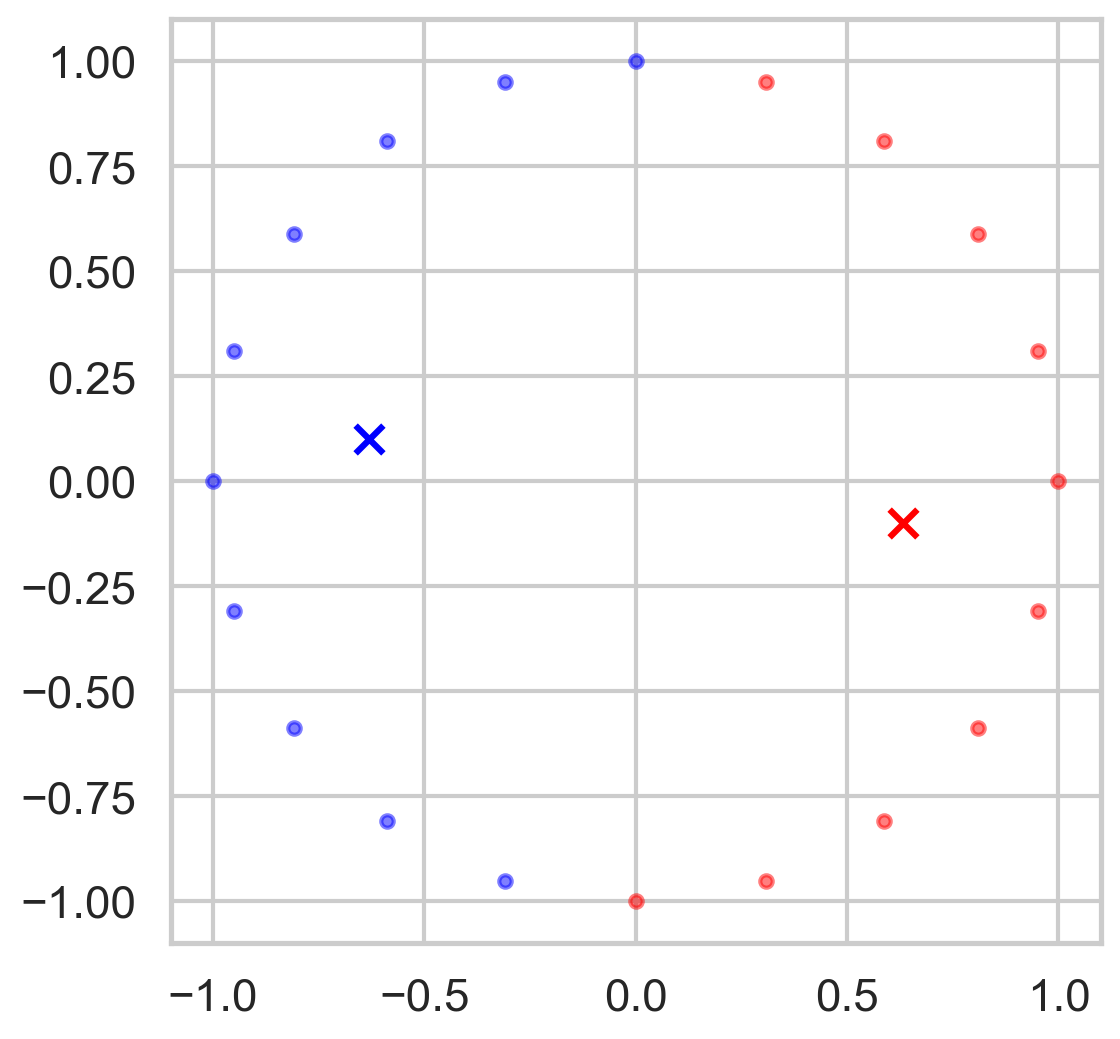

In [17]:
km = KMeans(n_clusters=num_clusters,              # Inicializa K-Means con k clusters
            random_state=20,                       # Cambia la semilla aleatoria
            n_init=1)                              # Número de ejecuciones del algoritmo
km.fit(X)                                          # Ajusta el modelo a los datos
display_cluster(X, km, num_clusters)               # Visualiza los nuevos clusters


Pregunta:

¿Por qué los clústeres son diferentes al ejecutar el K-means dos vece
Por la semilla, recordemos que k-means escoge aleatoriamente 2 puntos como **centroides**s?

Esto se debe a que los puntos de partida de los centros de los conglomerados influyen en la ubicación de los conglomerados finales. El punto de partida de los conglomerados está controlado por el estado aleatorio.


### Determinación del número óptimo de clústeres

Creemos un nuevo conjunto de datos que visualmente conste de varios clústeres e intentemos agruparlos.

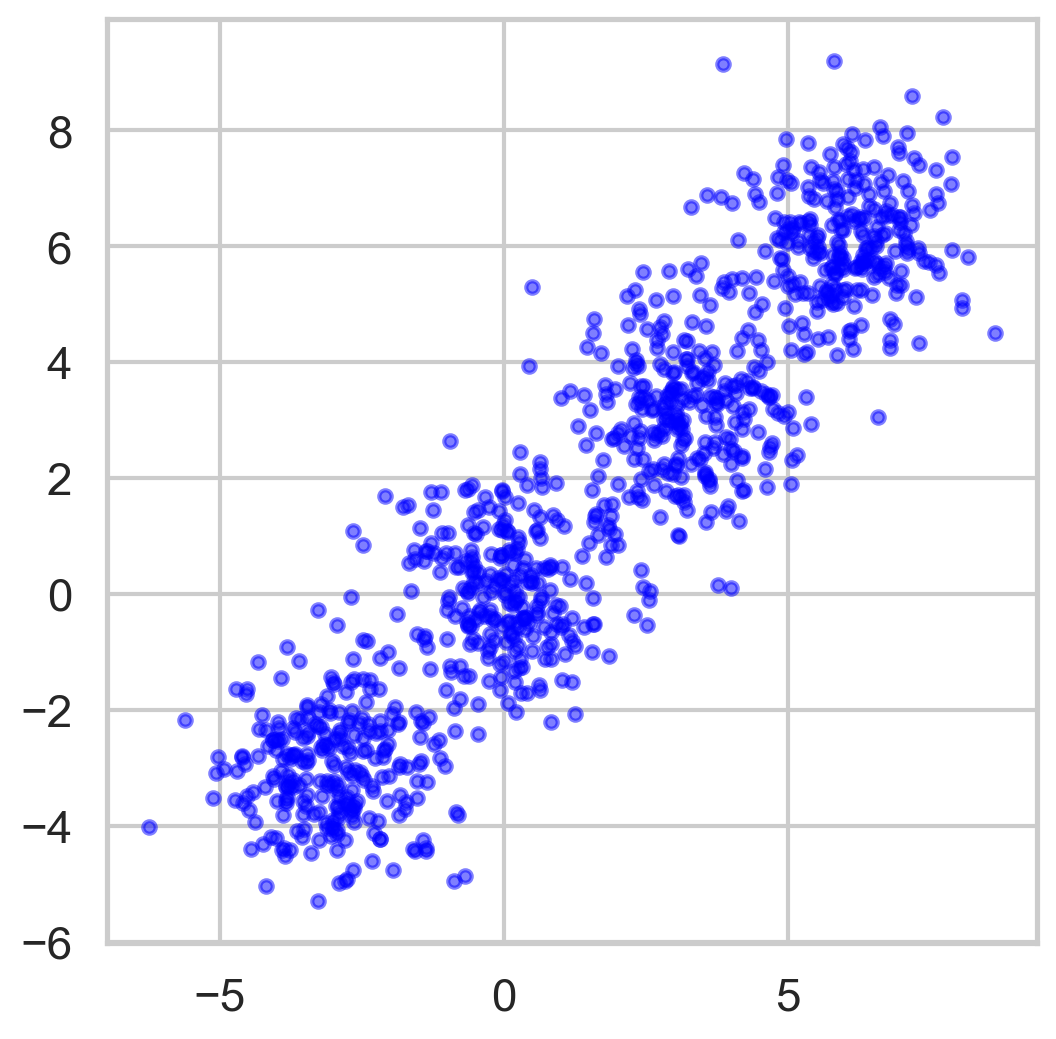

In [26]:
# Número total de muestras (puntos) que se van a generar
n_samples = 1000

# Número de bins o grupos (no se usa directamente aquí, pero suele representar la cantidad de clusters esperados)
n_bins = 4  

# Coordenadas de los centros de cada cluster Cada tupla representa el centro (x, y) de un grupo
centers = [(-3, -3), (0, 0), (3, 3), (6, 6)]

# Generación de datos sintéticos usando make_blobs

X, y = make_blobs(
    n_samples=n_samples, # n_samples: total de puntos
    n_features=2, # n_features: número de características (2 dimensiones)
    cluster_std=1.0, # cluster_std: desviación estándar de cada cluster
    centers=centers, # centers: posiciones de los centros de los clusters
    shuffle=False, # shuffle=False: mantiene el orden de los puntos por cluster
    random_state=42 # random_state: asegura reproducibilidad de los resultados
)

# Visualiza los datos generados mostrando los clusters
display_cluster(X)


¿Cuántos clústers observas?

Ejecutemos K-means con siete clústeres.

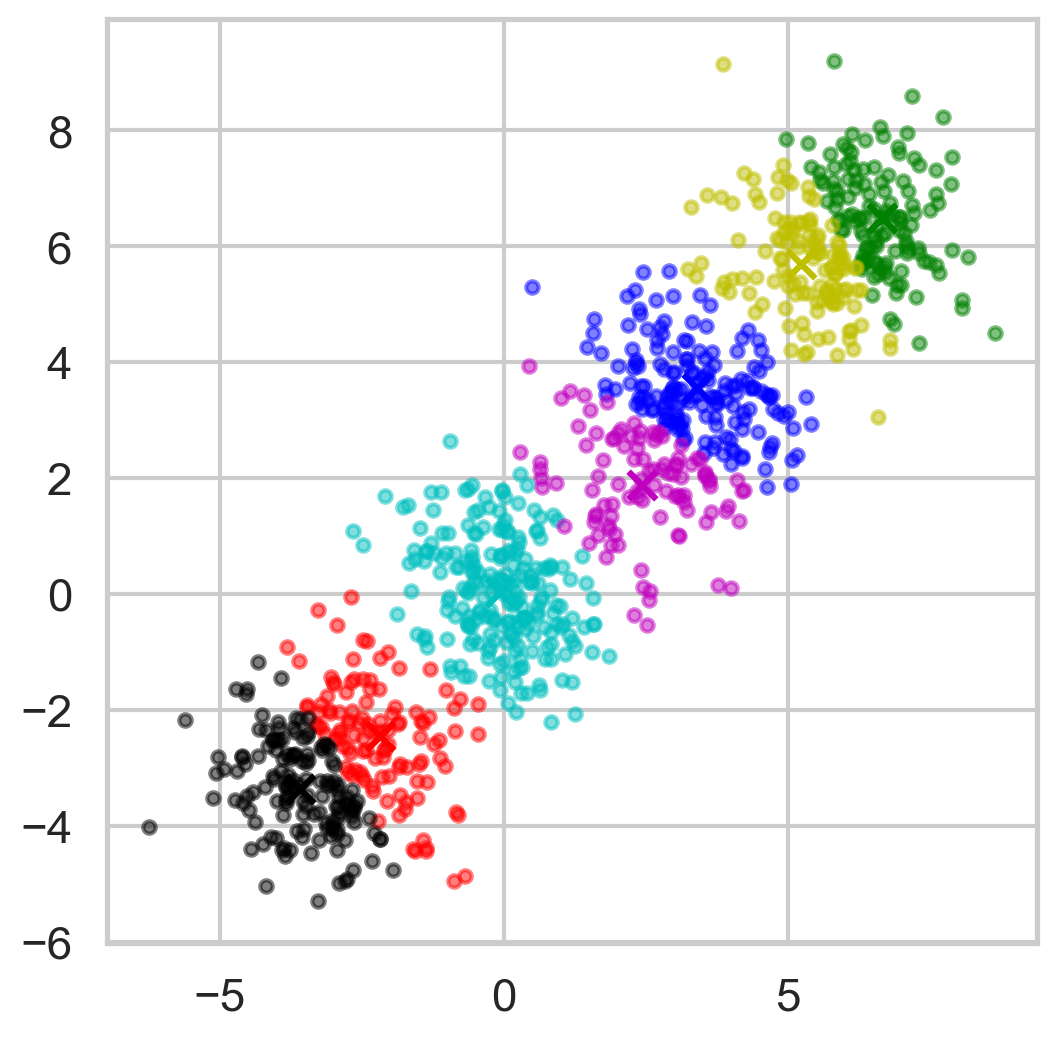

In [29]:
# Número de clusters que se desean formar con K-Means
num_clusters = 7

# Se crea el modelo K-Means indicando la cantidad de clusters
km = KMeans(n_clusters=num_clusters)

# Se ajusta (entrena) el modelo usando los datos X
# K-Means agrupa los puntos según su cercanía a los centroides
km.fit(X)

# Visualiza los clusters resultantes
# X: datos originales, km: modelo K-Means entrenado, num_clusters: número de clusters utilizados
display_cluster(X, km, num_clusters)


Ahora volvamos a ejecutar el algoritmo con cuatro clústeres.

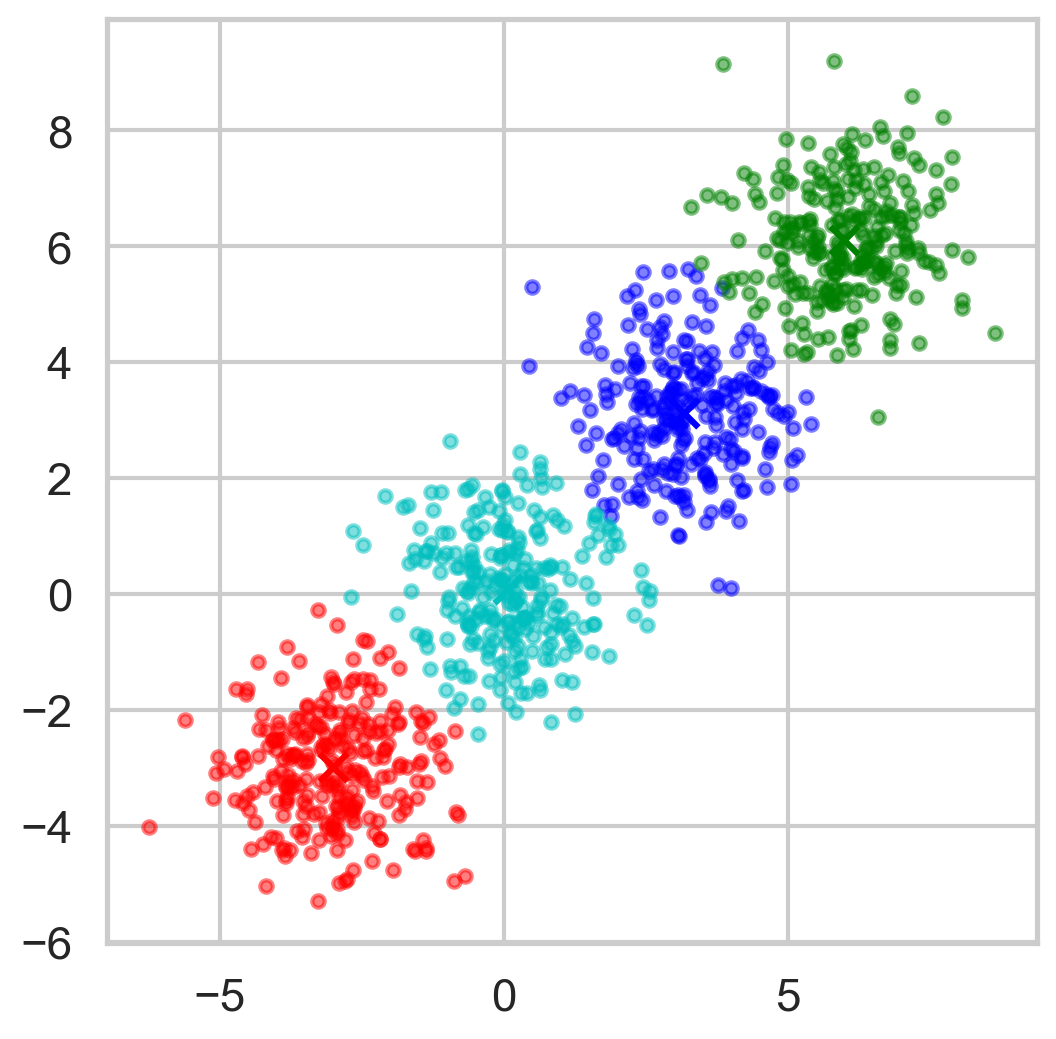

In [39]:
# Número de clusters que se desean formar (en este caso, 4)
num_clusters = 4

# Se crea el modelo K-Means especificando el número de clusters
km = KMeans(n_clusters=num_clusters)

# Se entrena el modelo con los datos X
# El algoritmo ajusta los centroides para minimizar la distancia entre los puntos y el centro de su cluster
km.fit(X)

# Muestra gráficamente los clusters obtenidos
# X: conjunto de datos, km: modelo K-Means ya entrenado, num_clusters: cantidad de clusters usados
display_cluster(X, km, num_clusters)


¿Deberíamos utilizar cuatro o siete clústeres?

En este caso, puede resultar visualmente obvio que cuatro clústeres son mejores que siete.

- Esto se debe a que podemos visualizar fácilmente los datos en un espacio bidimensional. Sin embargo, los datos del mundo real suelen tener más de dos dimensiones.

- Un conjunto de datos con un espacio dimensional mayor es difícil de visualizar.

- Una forma de resolver esto es graficar la **inercia**

**inercia**: (suma del error al cuadrado entre cada punto y el centro de su clúster) en función del número de clústeres.

In [45]:
km.inertia_

1880.2132513985368

## Problema 1:

Escribir código que calcule la inercia de 1 a 10 clústeres y representar gráficamente la inercia en función del número de clústeres.

Text(0, 0.5, 'Inertia')

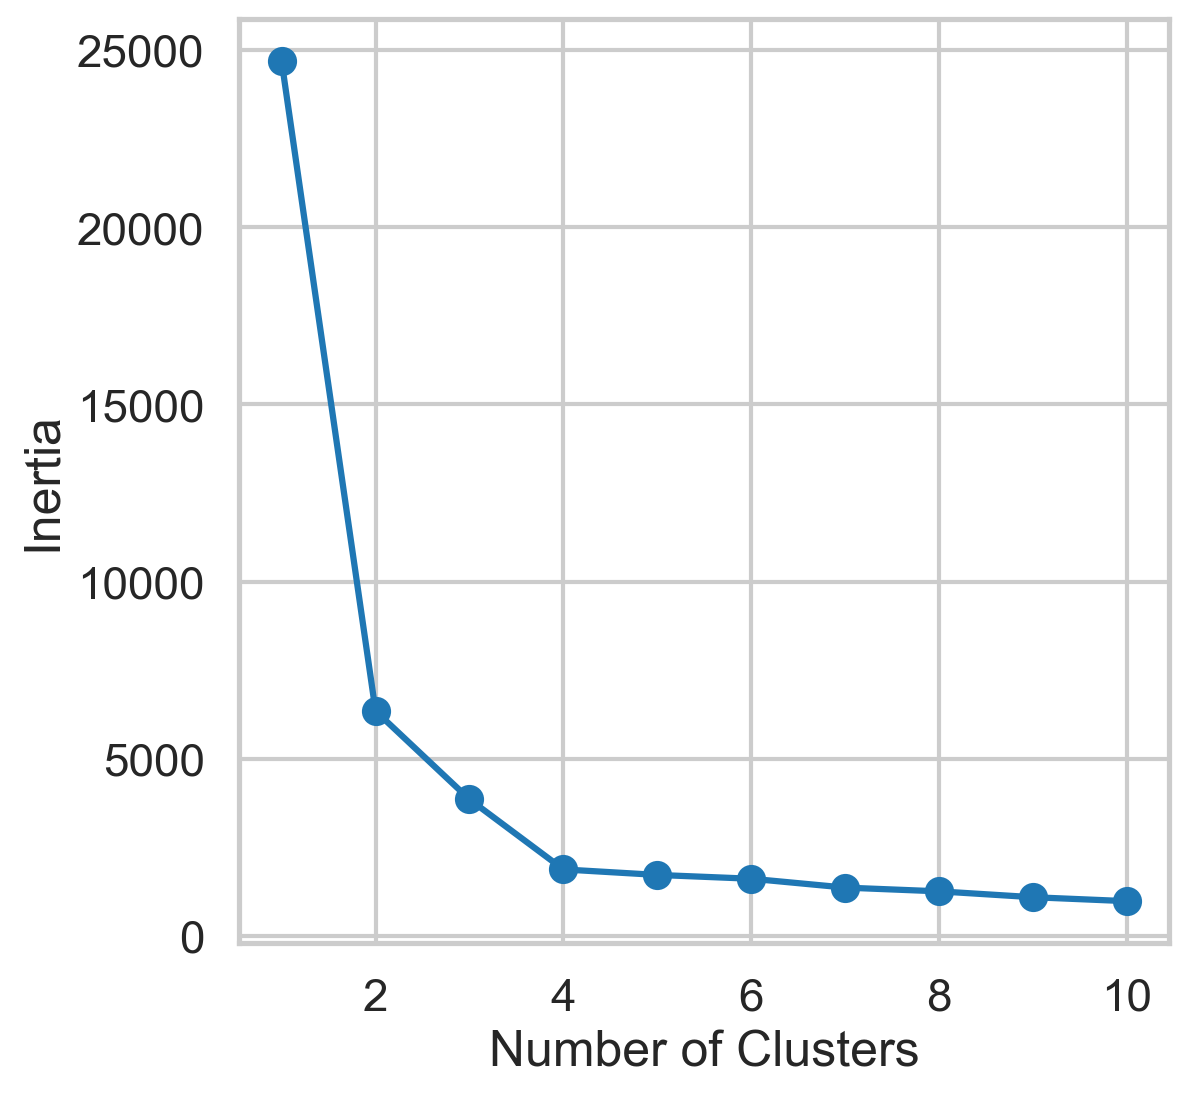

In [49]:
inertia = [] # Lista donde se almacenará la inercia para cada número de clusters

list_num_clusters = list(range(1, 11)) # Lista con los posibles valores de k (número de clusters), de 1 a 10

# Se itera sobre cada posible número de clusters
for num_clusters in list_num_clusters:
    km = KMeans(n_clusters=num_clusters) # Se crea el modelo K-Means con k clusters
    km.fit(X)     # Se entrena el modelo con los datos X
    
    # Se guarda la inercia del modelo: La inercia representa la suma de las distancias de los puntos a su centroide más cercano
    inertia.append(km.inertia_)

plt.plot(list_num_clusters, inertia) # Se grafica la relación entre el número de clusters y la inercia

plt.scatter(list_num_clusters, inertia) # Se añaden puntos a la gráfica para mayor claridad visual

plt.xlabel('Number of Clusters') # Etiqueta del eje X: número de clusters

plt.ylabel('Inertia') # Etiqueta del eje Y: inercia

¿Dónde se encuentra el codo de la curva?

¿Cuál crees que sería la inercia si tuvieras el mismo número de clústeres y puntos de datos?

### Agrupamiento de colores de una imagen

Los siguientes ejercicios usan una imagen de pimientos morrones. Comencemos cargándola:

(-0.5, 639.5, 479.5, -0.5)

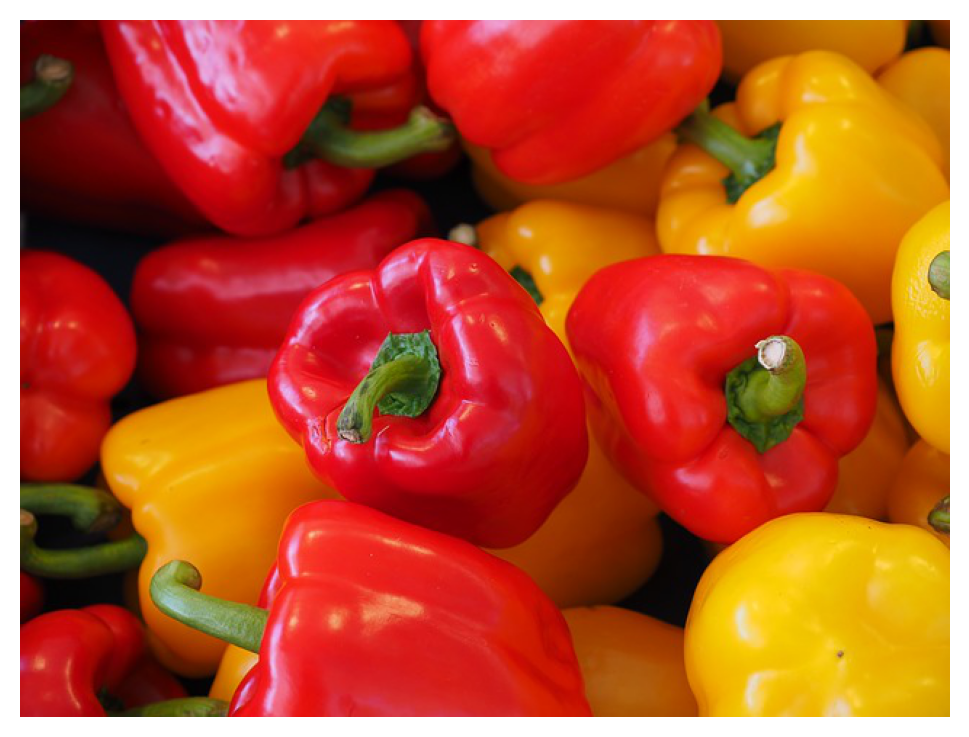

In [127]:
# Carga la imagen desde la ruta especificada
# plt.imread lee la imagen y la convierte en un arreglo de píxeles
# format='jpeg' indica el formato de la imagen
img = plt.imread(
    'Imagen/peppers.jpg',
    format='jpeg'
)

# Muestra la imagen cargada
plt.imshow(img)

# Oculta los ejes para una visualización más limpia
plt.axis('off')


In [62]:
img #arreglo de píxeles

array([[[ 15,  18,  25],
        [ 26,  16,  24],
        [ 42,  15,  22],
        ...,
        [129,  48,   1],
        [132,  50,   2],
        [134,  50,   3]],

       [[ 24,  17,  25],
        [ 30,  15,  22],
        [ 45,  12,  19],
        ...,
        [123,  45,   0],
        [127,  46,   0],
        [129,  47,   0]],

       [[ 36,  15,  24],
        [ 42,  12,  20],
        [ 52,  11,  17],
        ...,
        [119,  42,   0],
        [122,  43,   0],
        [123,  44,   1]],

       ...,

       [[182,  18,  27],
        [183,  19,  28],
        [184,  20,  29],
        ...,
        [207, 156,   3],
        [207, 156,   3],
        [207, 156,   3]],

       [[182,  18,  27],
        [184,  20,  29],
        [185,  21,  30],
        ...,
        [206, 155,   2],
        [206, 155,   2],
        [206, 155,   2]],

       [[184,  20,  29],
        [186,  22,  31],
        [186,  22,  33],
        ...,
        [205, 154,   1],
        [205, 154,   3],
        [206, 155,   4]]

In [56]:
img.shape

(480, 640, 3)

La imagen de arriba tiene 480 píxeles de alto y 640 de ancho. Cada píxel tiene 3 valores que representan la cantidad de rojo, verde y azul. A continuación, puedes experimentar con diferentes combinaciones de RGB para crear diferentes colores. En total, puedes crear 256^3 = 16 777 216 colores únicos.

(-0.5, 0.5, 0.5, -0.5)

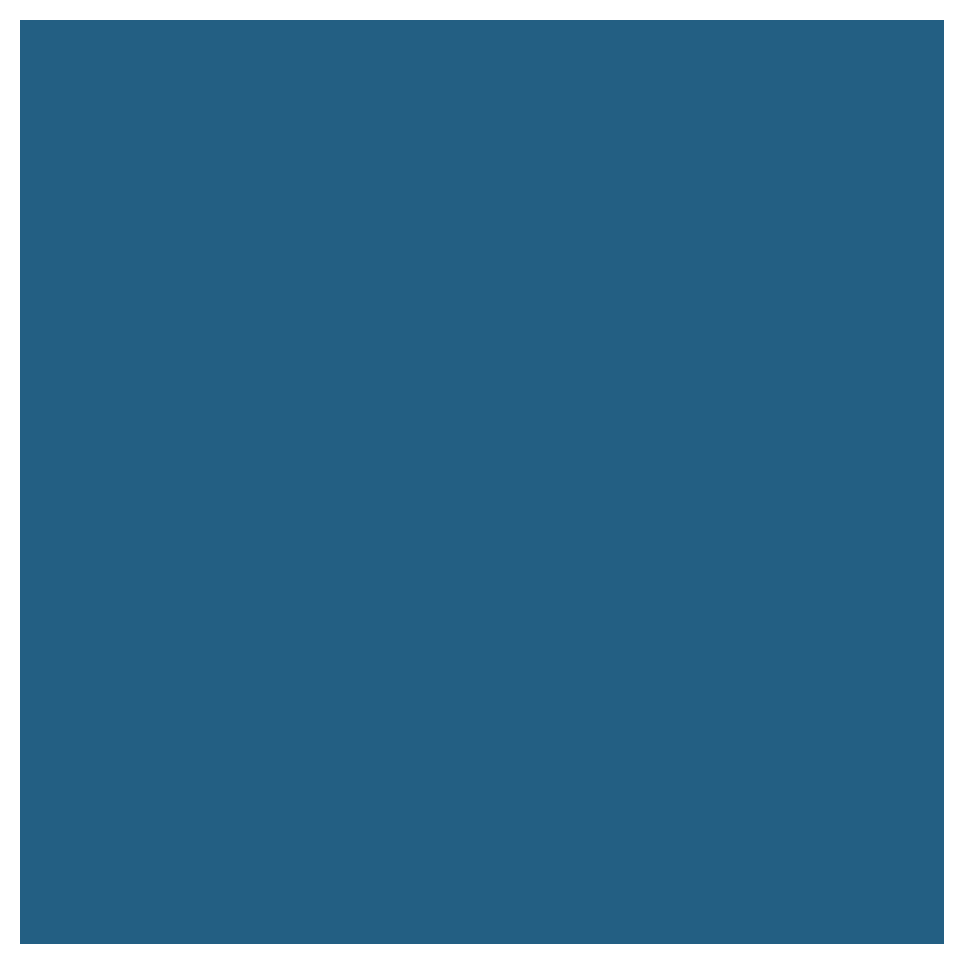

In [65]:
# Asignación de valores para los canales RGB
# Cada valor debe estar entre 0 y 255
R = 35   # Intensidad del color rojo
G = 95   # Intensidad del color verde
B = 131  # Intensidad del color azul

# Se crea un arreglo NumPy con los valores RGB
# astype('uint8') convierte los valores al tipo adecuado para imágenes
plt.imshow([[np.array([R, G, B]).astype('uint8')]])

# Oculta los ejes para mostrar únicamente el color
plt.axis('off')


Primero, remodelaremos la imagen en una tabla que tiene un píxel por fila y cada columna representa el canal rojo, verde y azul.

In [67]:
# Se redimensiona la imagen para convertirla en una matriz 2D
# -1 indica que NumPy calcula automáticamente el número de filas
# 3 corresponde a los canales RGB de cada píxel
img_flat = img.reshape(-1, 3)

# Muestra los primeros 5 píxeles de la imagen aplanada
# Cada fila representa un píxel con sus valores RGB
img_flat[:5, :]


array([[15, 18, 25],
       [26, 16, 24],
       [42, 15, 22],
       [65, 16, 22],
       [85, 14, 22]], dtype=uint8)

¡Como hay 480x640 píxeles, obtenemos 307.200 filas!

In [70]:
img_flat.shape

(307200, 3)

Ejecutemos K-means con 8 clústeres.


In [75]:
# Se crea y entrena el modelo K-Means para la imagen
kmeans = KMeans(n_clusters=8, # n_clusters=8 indica que la imagen se reducirá a 8 colores principales
                random_state=0 # random_state=0 asegura que los resultados sean reproducibles
               ).fit(img_flat) # fit(img_flat) entrena el modelo usando los píxeles aplanados (RGB)


Ahora reemplacemos cada fila con su centro de grupo más cercano.

In [82]:
kmeans.labels_

array([0, 0, 0, ..., 2, 2, 2])

In [80]:
# Se crea una copia del arreglo de píxeles original
# Esto evita modificar directamente la imagen aplanada original
img_flat2 = img_flat.copy()
# Se itera sobre cada etiqueta de cluster única. Cada etiqueta corresponde a un color representativo
for i in np.unique(kmeans.labels_):
    # Se reemplazan los valores RGB de todos los píxeles que pertenecen al cluster i por el centroide del cluster
    # Esto reduce la cantidad de colores en la imagen
    img_flat2[kmeans.labels_ == i, :] = kmeans.cluster_centers_[i]

In [87]:
img_flat2

array([[ 43,  15,   6],
       [ 43,  15,   6],
       [ 43,  15,   6],
       ...,
       [236, 172,   7],
       [236, 172,   7],
       [236, 172,   7]], dtype=uint8)

Ahora necesitamos reformular los datos de 307.200 x 3 a 480 x 640 x 3

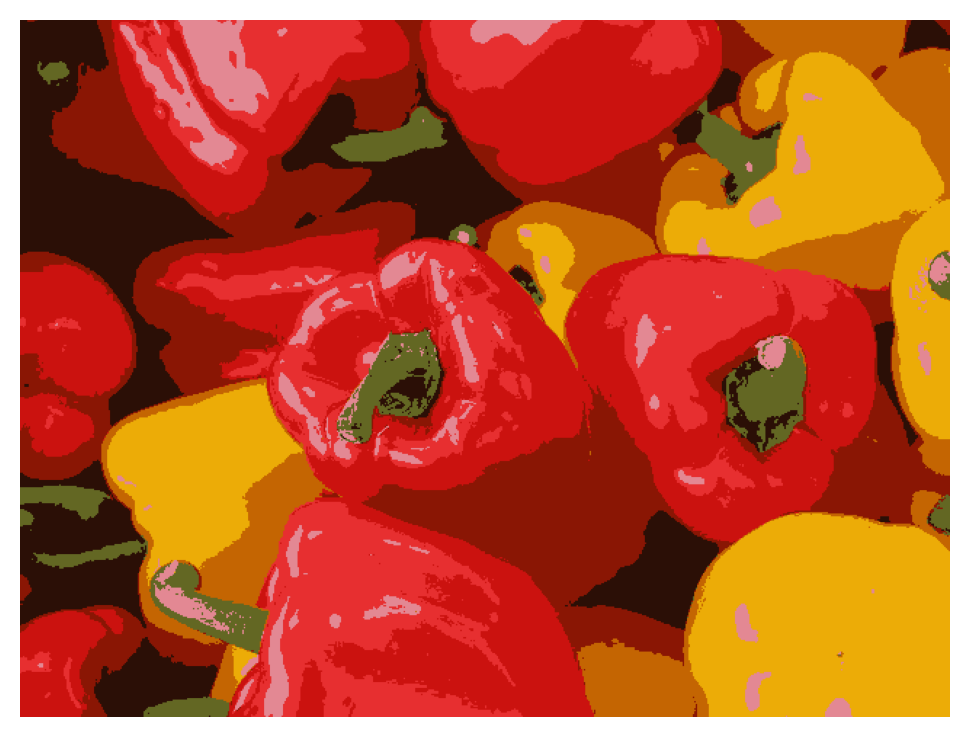

In [84]:
# Se reconstruye la imagen a su forma original
# img.shape asegura que se mantengan las dimensiones originales (alto, ancho, RGB)
img2 = img_flat2.reshape(img.shape)

# Muestra la imagen resultante después de la compresión con K-Means
plt.imshow(img2)

# Oculta los ejes para una visualización más limpia
plt.axis('off')

### Problema 2:
Escribe una función que reciba la imagen y el número de clústeres (k), y devuelva (1) la imagen cuantificada en k colores, y (2) la inercia.

In [110]:
def image_cluster(img, k):
    # Aplanamos la imagen: de (alto, ancho, 3) a (alto*ancho, 3)
    # Cada fila representa un píxel con sus valores RGB
    img_flat = img.reshape(img.shape[0] * img.shape[1], 3)
    
    # Aplicamos K-Means para agrupar los píxeles en k clusters
    # Cada cluster representará un color dominante
    kmeans = KMeans(n_clusters=k, random_state=0).fit(img_flat)
    
    # Copiamos la imagen aplanada para no modificar la original
    img_flat2 = img_flat.copy()

    # Recorremos cada cluster encontrado
    for i in np.unique(kmeans.labels_):
        # Reemplazamos los píxeles del cluster i
        # por el color del centroide correspondiente
        img_flat2[kmeans.labels_ == i, :] = kmeans.cluster_centers_[i]
        
    # Regresamos la imagen a su forma original (alto, ancho, 3)
    img2 = img_flat2.reshape(img.shape)

    # Oculta los ejes para una visualización más limpia
    #plt.axis('off')
    
    # Retornamos:
    # - img2: imagen segmentada por colores
    # - kmeans.inertia_: qué tan compactos quedaron los clusters
    return img2, kmeans.inertia_


### Problema 3:

Llame a la función para k entre 2 y 20 y dibuje una curva de inercia. ¿Cuál es el número óptimo de clústeres?

In [121]:
# Lista de valores de k (número de clusters) desde 2 hasta 20, de 2 en 2
k_vals = list(range(2, 21, 2))

img_list = [] # Lista para almacenar las imágenes resultantes de la compresión

inertia = [] # Lista para guardar la inercia asociada a cada valor de k

for k in k_vals: # Se itera sobre cada valor de k
    # Aplica clustering a la imagen con k clusters
    img2, ine = image_cluster(img, k) # img2 es la imagen comprimida, ine es la inercia del modelo K-Means
    img_list.append(img2)# Se guarda la imagen resultante en la lista
    inertia.append(ine) # Se guarda la inercia correspondiente

Text(0, 0.5, 'Inertia')

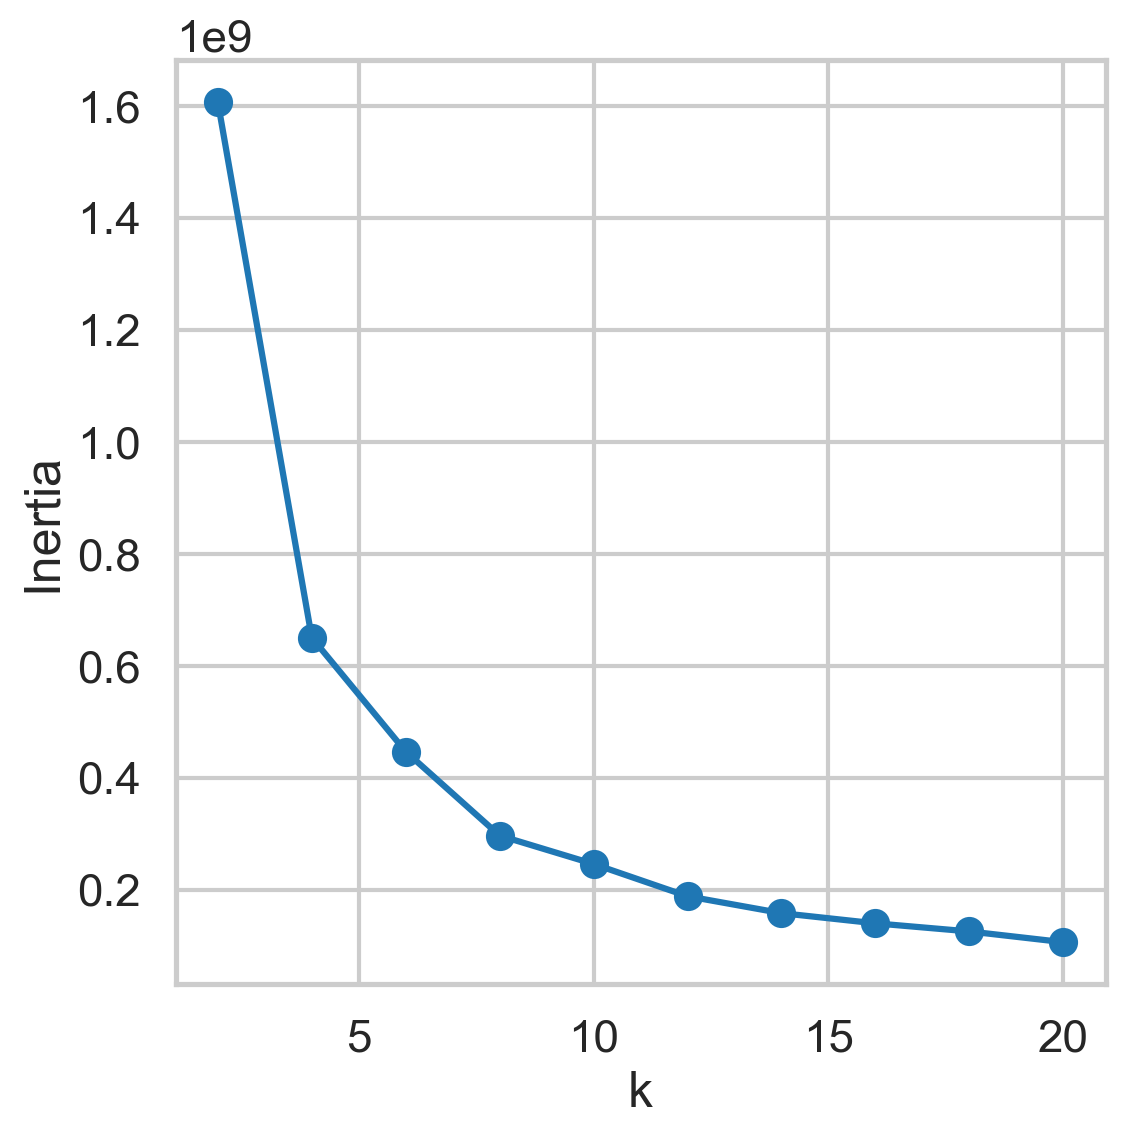

In [123]:
plt.plot(k_vals, inertia) # Grafica la inercia en función del número de clusters k
plt.scatter(k_vals, inertia) # Agrega puntos para resaltar cada valor de k evaluado
plt.xlabel('k') # Etiqueta del eje X: número de clusters (k)
plt.ylabel('Inertia') # Etiqueta del eje Y: inercia del modelo K-Means

En ocasiones, el método del codo no proporciona una decisión clara (por ejemplo, si el codo no es claro ni preciso, o si es ambiguo). En tales casos, alternativas como el **coeficiente de silueta** pueden ser útiles.

### Problema 4:
Grafica en una cuadrícula todas las imágenes para los diferentes valores k.

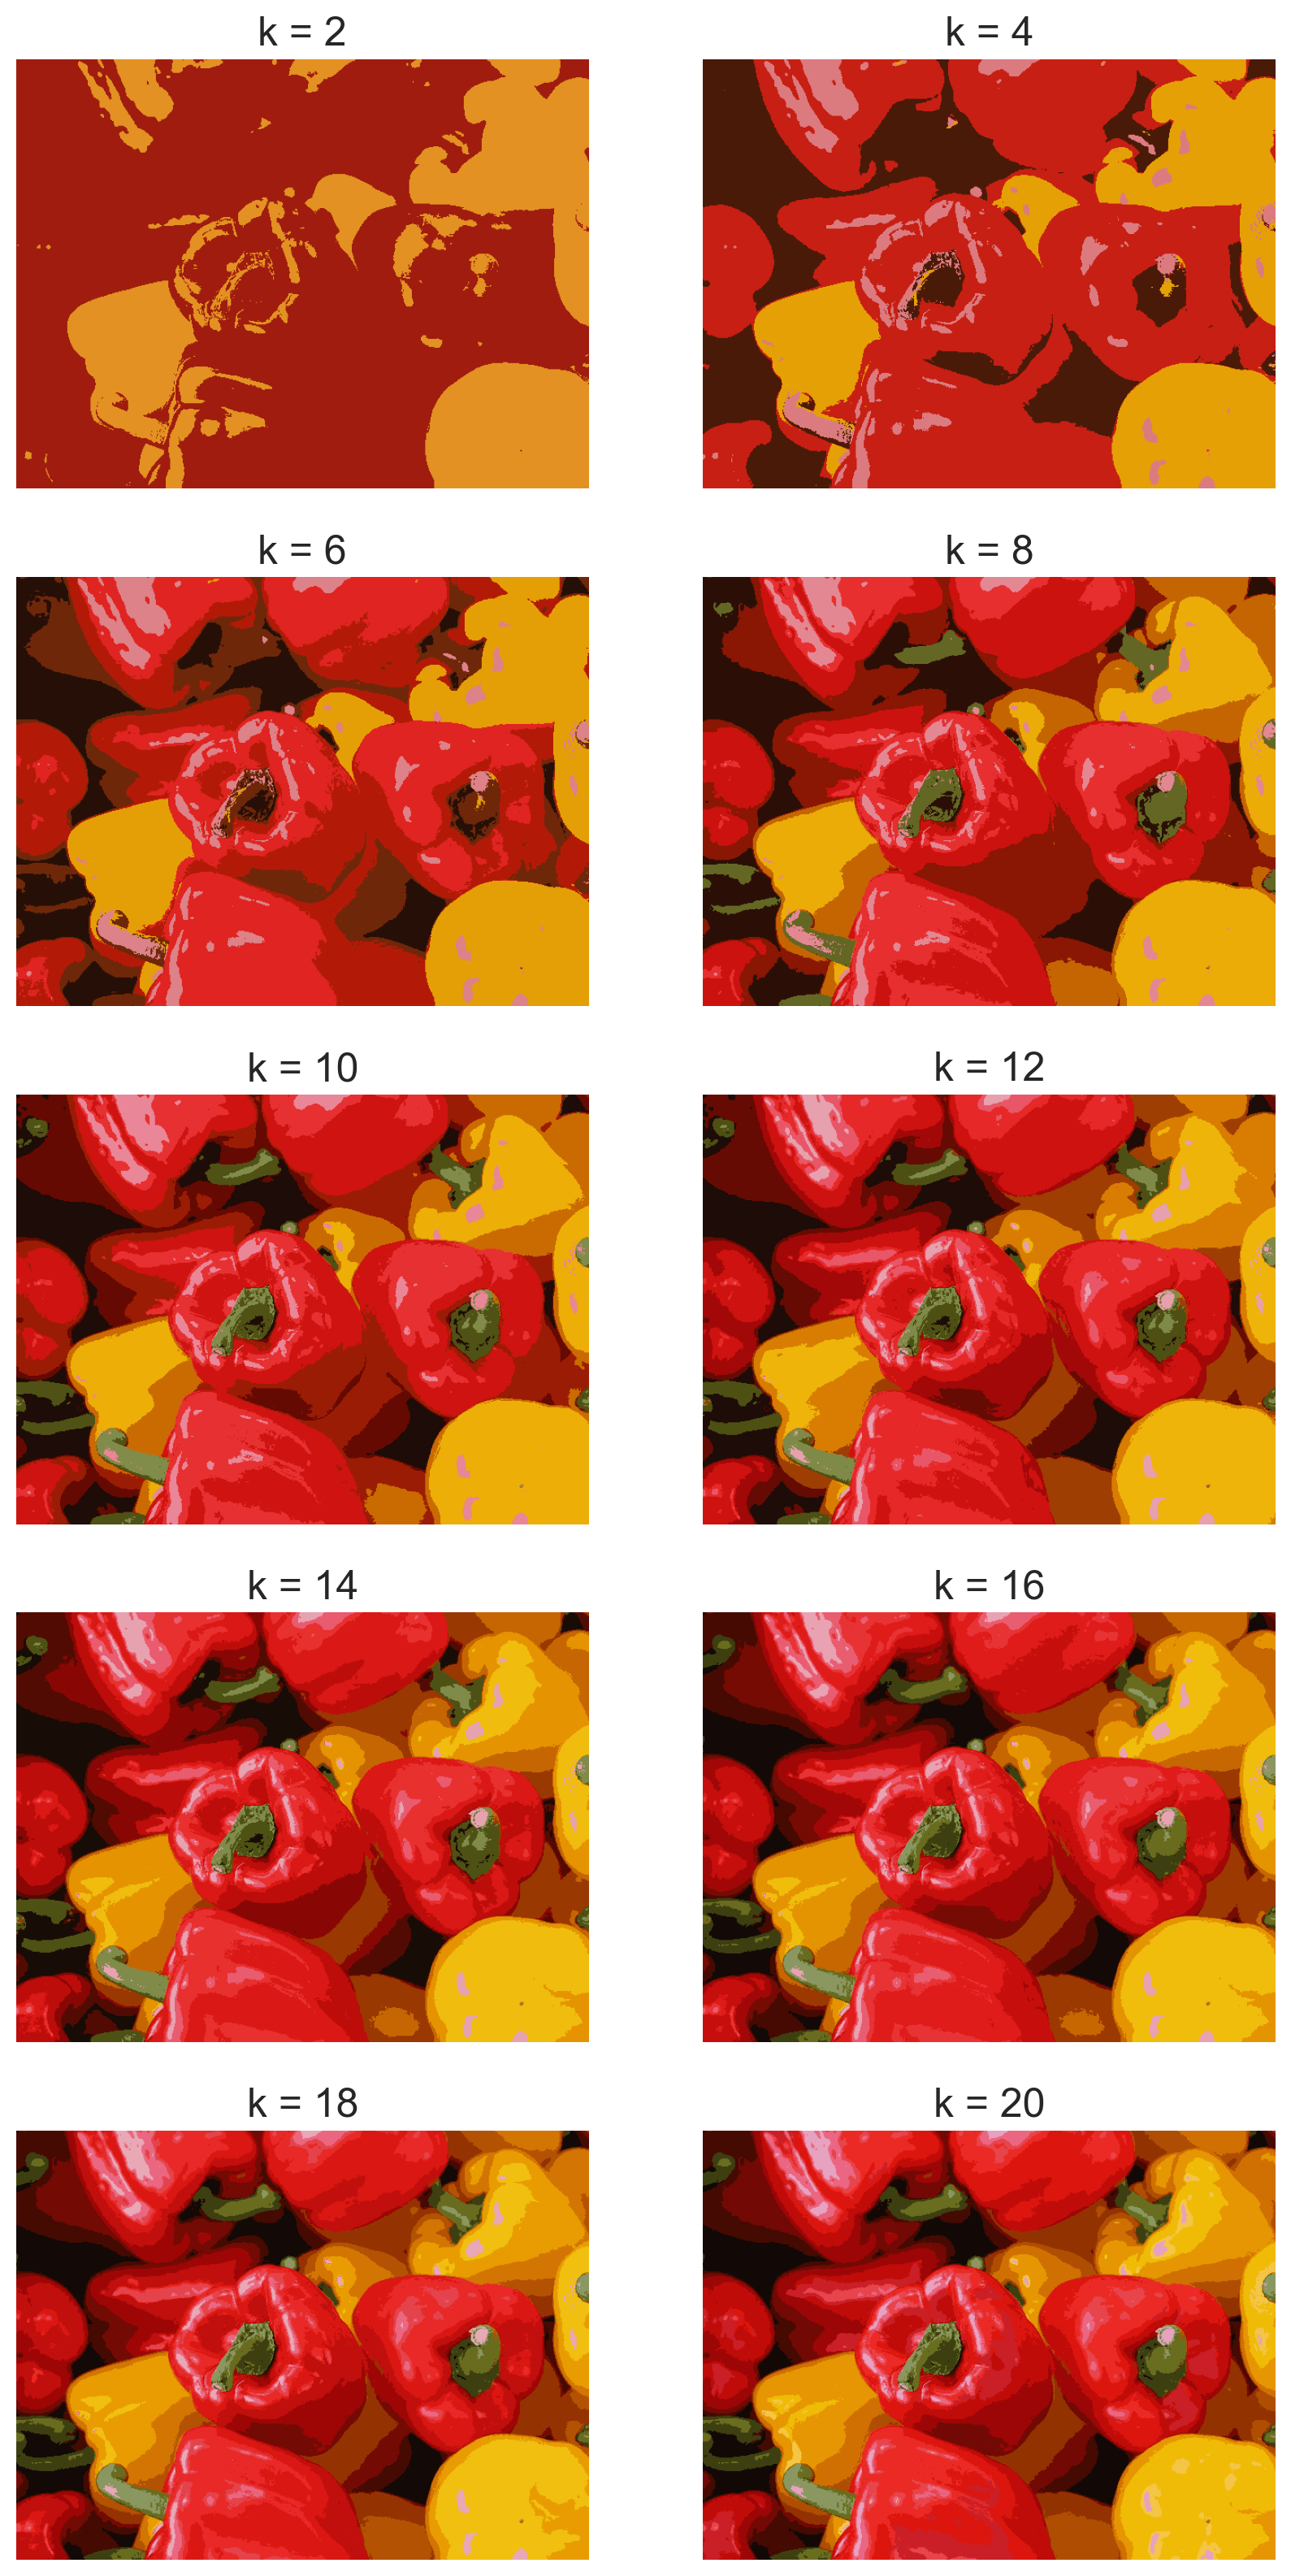

In [125]:
plt.figure(figsize=[10, 20]) # Se crea una figura con un tamaño grande para visualizar varias imágenes


# Se recorre la lista de valores de k
for i in range(len(k_vals)):
    
    # Se crea un subplot en una cuadrícula de 5 filas por 2 columnas
    # i+1 indica la posición del subplot
    plt.subplot(5, 2, i + 1)
    
    # Muestra la imagen comprimida correspondiente a ese valor de k
    plt.imshow(img_list[i])
    
    # Título indicando el número de clusters utilizados
    plt.title('k = ' + str(k_vals[i]))
    
    # Oculta los ejes para una mejor visualización
    plt.axis('off')